In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

df = pd.read_csv('../data/raw/air_quality.csv')
print("Loaded!", df.shape)

Loaded! (29531, 16)


In [2]:
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 
                  'NH3', 'CO', 'SO2', 'O3', 'Benzene', 
                  'Toluene', 'Xylene']

# Before
missing_before = df[pollutant_cols].isnull().sum()

# Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5)
df[pollutant_cols] = imputer.fit_transform(df[pollutant_cols])

# After
missing_after = df[pollutant_cols].isnull().sum()

print("Missing BEFORE:\n", missing_before)
print("\nMissing AFTER:\n", missing_after)

Missing BEFORE:
 PM2.5       4598
PM10       11140
NO          3582
NO2         3585
NOx         4185
NH3        10328
CO          2059
SO2         3854
O3          4022
Benzene     5623
Toluene     8041
Xylene     18109
dtype: int64

Missing AFTER:
 PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
dtype: int64


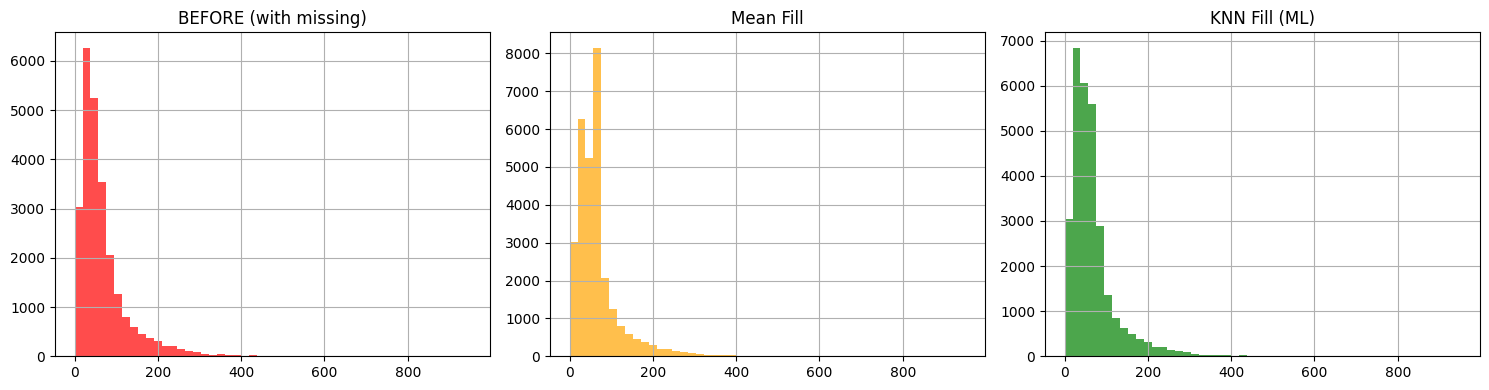

✅ Plot saved!


In [3]:
# Reload original to compare
df_original = pd.read_csv('../data/raw/air_quality.csv')

# Mean fill
df_mean = df_original.copy()
df_mean['PM2.5'] = df_mean['PM2.5'].fillna(df_mean['PM2.5'].mean())

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_original['PM2.5'].hist(bins=50, ax=axes[0], color='red', alpha=0.7)
axes[0].set_title('BEFORE (with missing)')

df_mean['PM2.5'].hist(bins=50, ax=axes[1], color='orange', alpha=0.7)
axes[1].set_title('Mean Fill')

df['PM2.5'].hist(bins=50, ax=axes[2], color='green', alpha=0.7)
axes[2].set_title('KNN Fill (ML)')

plt.tight_layout()
plt.savefig('../reports/before_plots/pm25_imputation_comparison.png')
plt.show()
print("✅ Plot saved!")

In [4]:
df.to_csv('../data/processed/step1_missing_fixed.csv', index=False)
print("✅ Saved to data/processed/step1_missing_fixed.csv")

✅ Saved to data/processed/step1_missing_fixed.csv
